# Chi-Square Test Analysis

Use Chi-Square (χ²) test of independence to evaluate relationships between categorical variables and loan approval status.

## Theory: Chi-Square Test of Independence

Tests whether two categorical variables are independent.

- **H₀ (Null Hypothesis):** The two variables are independent.
- **H₁ (Alternative Hypothesis):** The two variables are dependent.

Formula:
$$
\chi^2 = \sum \frac{(O_{ij} - E_{ij})^2}{E_{ij}}
$$

Where:
- $O_{ij}$: Observed frequency
- $E_{ij}$: Expected frequency = (Row total × Column total) / Grand total

If **p-value < 0.05**, reject H₀ (variables are dependent).

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style='darkgrid', palette='pastel')
plt.rcParams.update({
    'grid.color': '0.3',
    'axes.facecolor': '#1c1c1c',
    'figure.facecolor': '#121212',
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white'
})

# 2. Load Data

Load pre-cleaned data (encoded, whitespace removed) from `data/process/loan_data_cleaned.csv`.

In [2]:
df = pd.read_csv('data/process/loan_data_cleaned.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (4269, 18)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,total_assets_value,loan_to_income_ratio,assets_to_loan_ratio,income_per_dependent,loan_per_term
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,50700000,3.114583,1.695652,3.200000e+06,2.491667e+06
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,17000000,2.975610,1.393443,4.100000e+06,1.525000e+06
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,57700000,3.263736,1.942761,2.275000e+06,1.485000e+06
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,52700000,3.743902,1.716612,2.050000e+06,3.837500e+06
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,55000000,2.469388,2.272727,1.633333e+06,1.210000e+06


In [3]:
# Label mapping for readable display
label_map = {
    'education': {0: 'Not Graduate', 1: 'Graduate'},
    'self_employed': {0: 'No', 1: 'Yes'},
    'loan_status': {0: 'Rejected', 1: 'Approved'},
}

print("education:", df['education'].value_counts().to_dict())
print("self_employed:", df['self_employed'].value_counts().to_dict())
print("loan_status:", df['loan_status'].value_counts().to_dict())

education: {1: 2144, 0: 2125}
self_employed: {1: 2150, 0: 2119}
loan_status: {1: 2656, 0: 1613}


---
# 3. Hypothesis 1: Education vs Loan Status

**Question:** Is there a relationship between education level (Graduate/Not Graduate) and loan approval?

- **H₀:** Education and Loan Status are independent.
- **H₁:** Education and Loan Status are dependent.

In [4]:
# Contingency table with readable labels
ct_edu = pd.crosstab(
    df['education'].map(label_map['education']),
    df['loan_status'].map(label_map['loan_status']),
    margins=True,
    margins_name='Total'
)
print("Contingency Table: Education vs Loan Status")
ct_edu

Contingency Table: Education vs Loan Status


loan_status,Approved,Rejected,Total
education,,,
Graduate,1339,805,2144
Not Graduate,1317,808,2125
Total,2656,1613,4269


In [5]:
# Chi-Square test
crosstab_edu = pd.crosstab(df['education'], df['loan_status'])
chi2, p, dof, expected = chi2_contingency(crosstab_edu)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.6f}")
print(f"\nExpected frequencies:\n{np.round(expected, 2)}")

Chi-square statistic: 0.0840
Degrees of freedom: 1
P-value: 0.772004

Expected frequencies:
[[ 802.91 1322.09]
 [ 810.09 1333.91]]


In [6]:
alpha = 0.05
if p < alpha:
    print(">>> Conclusion: Reject H₀ (p-value < 0.05)")
    print(">>> There is a significant relationship between Education and Loan Status.")
else:
    print(">>> Conclusion: Fail to reject H₀ (p-value >= 0.05)")
    print(">>> Education and Loan Status are independent.")

>>> Conclusion: Fail to reject H₀ (p-value >= 0.05)
>>> Education and Loan Status are independent.


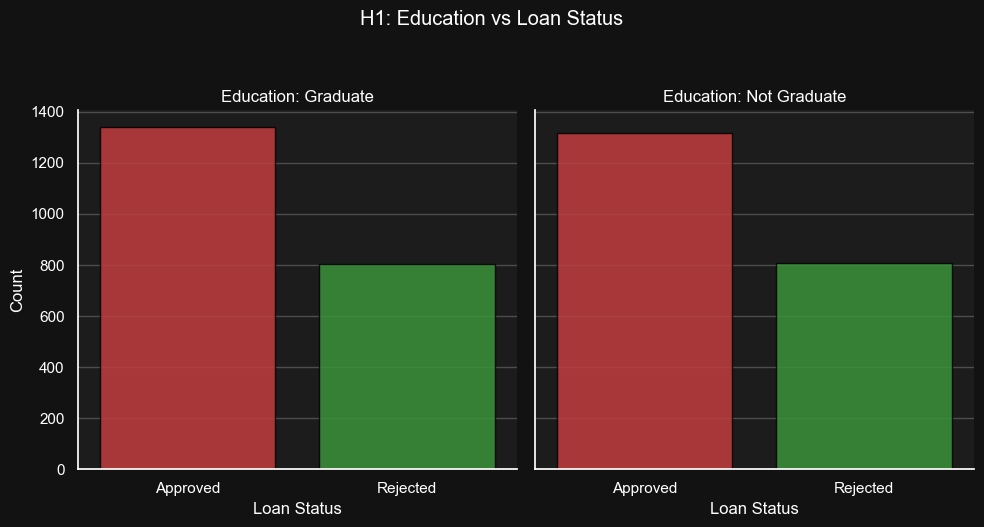

In [7]:
# Faceted count plot: one chart per education level
edu_plot = df[['education', 'loan_status']].copy()
edu_plot['education'] = edu_plot['education'].map(label_map['education'])
edu_plot['loan_status'] = edu_plot['loan_status'].map(label_map['loan_status'])

g = sns.catplot(
    data=edu_plot, col='education', x='loan_status', hue='loan_status',
    kind='count', palette=['#d62728', '#2ca02c'],
    edgecolor='black', alpha=0.85, sharey=True, legend=False
)
g.set_axis_labels('Loan Status', 'Count')
g.set_titles(col_template='Education: {col_name}')
g.fig.suptitle('H1: Education vs Loan Status', y=1.05)
plt.tight_layout()
g.savefig('reports/images/chi_square/education_vs_loan_status.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 4. Hypothesis 2: Self-Employed vs Loan Status

**Question:** Does self-employment status affect the likelihood of loan approval?

- **H₀:** Self-Employed and Loan Status are independent.
- **H₁:** Self-Employed and Loan Status are dependent.

In [8]:
# Contingency table with readable labels
ct_se = pd.crosstab(
    df['self_employed'].map(label_map['self_employed']),
    df['loan_status'].map(label_map['loan_status']),
    margins=True,
    margins_name='Total'
)
print("Contingency Table: Self-Employed vs Loan Status")
ct_se

Contingency Table: Self-Employed vs Loan Status


loan_status,Approved,Rejected,Total
self_employed,,,
No,1318,801,2119
Yes,1338,812,2150
Total,2656,1613,4269


In [9]:
# Chi-Square test
crosstab_se = pd.crosstab(df['self_employed'], df['loan_status'])
chi2_se, p_se, dof_se, expected_se = chi2_contingency(crosstab_se)

print(f"Chi-square statistic: {chi2_se:.4f}")
print(f"Degrees of freedom: {dof_se}")
print(f"P-value: {p_se:.6f}")
print(f"\nExpected frequencies:\n{np.round(expected_se, 2)}")

Chi-square statistic: 0.0000
Degrees of freedom: 1
P-value: 1.000000

Expected frequencies:
[[ 800.64 1318.36]
 [ 812.36 1337.64]]


In [10]:
if p_se < alpha:
    print(">>> Conclusion: Reject H₀ (p-value < 0.05)")
    print(">>> There is a significant relationship between Self-Employed and Loan Status.")
else:
    print(">>> Conclusion: Fail to reject H₀ (p-value >= 0.05)")
    print(">>> Self-Employed and Loan Status are independent.")

>>> Conclusion: Fail to reject H₀ (p-value >= 0.05)
>>> Self-Employed and Loan Status are independent.


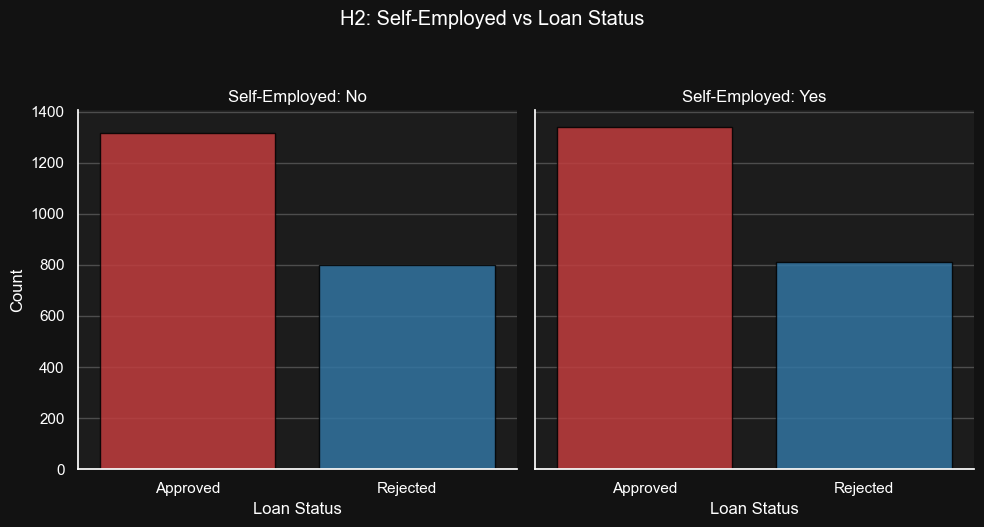

In [11]:
# Faceted count plot: one chart per self-employed status
se_plot = df[['self_employed', 'loan_status']].copy()
se_plot['self_employed'] = se_plot['self_employed'].map(label_map['self_employed'])
se_plot['loan_status'] = se_plot['loan_status'].map(label_map['loan_status'])

g = sns.catplot(
    data=se_plot, col='self_employed', x='loan_status', hue='loan_status',
    kind='count', palette=['#d62728', '#1f77b4'],
    edgecolor='black', alpha=0.85, sharey=True, legend=False
)
g.set_axis_labels('Loan Status', 'Count')
g.set_titles(col_template='Self-Employed: {col_name}')
g.fig.suptitle('H2: Self-Employed vs Loan Status', y=1.05)
plt.tight_layout()
g.savefig('reports/images/chi_square/self_employed_vs_loan_status.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 5. Summary

In [12]:
# Summary table with dynamic results
h1_concl = 'Reject H0' if p < alpha else 'Fail to reject H0'
h2_concl = 'Reject H0' if p_se < alpha else 'Fail to reject H0'

summary = pd.DataFrame({
    'Hypothesis': ['H1', 'H2'],
    'Variables': ['Education vs Loan Status', 'Self-Employed vs Loan Status'],
    'χ²': [f'{chi2:.4f}', f'{chi2_se:.4f}'],
    'p-value': [f'{p:.6f}', f'{p_se:.6f}'],
    'Conclusion': [h1_concl, h2_concl]
})
print("Chi-Square Test Results")
summary

print("\nFindings:")
if p < alpha:
    print("- H1: Education significantly affects loan approval.")
else:
    print("- H1: Education does NOT significantly affect loan approval.")
if p_se < alpha:
    print("- H2: Self-Employed status significantly affects loan approval.")
else:
    print("- H2: Self-Employed status does NOT significantly affect loan approval.")

Chi-Square Test Results

Findings:
- H1: Education does NOT significantly affect loan approval.
- H2: Self-Employed status does NOT significantly affect loan approval.
